# FAIR Dynamic LCIA Demo

This notebook showcases the **FAIR climate-model** path of the [`dynamic_characterization`](https://github.com/brightway-lca/dynamic_characterization) package.

Unlike the per-species impulse-response metrics (`radiative_forcing`, `GWP`, `pGWP`, ...), the FAIR path runs the full [FaIR](https://github.com/OMS-NetZero/FAIR) simple climate-model **ensemble** (the calibrated, constrained AR6 set of 841 members) on top of an SSP background scenario. It returns the **change in radiative forcing (ΔRF, W/m²)** and **change in global mean surface temperature (ΔT, K)** attributable to your inventory, with **ensemble uncertainty (quantiles)** and **per-flow / per-activity attribution**.

Two metrics are added to `characterize()`:

- **`fair_radiative_forcing`** → ΔRF [W/m²]
- **`fair_temperature`** → ΔT [K]

Both return a long `DataFrame` with an extra **`quantile`** column.

## 0. Install

FAIR is an optional dependency:

```console
$ pip install dynamic_characterization[fair]
```

> The calibrated AR6 ensemble is **not** bundled in `fair`; it is downloaded and cached (via `pooch`) on the **first** FAIR run, so the first call needs network access.

## 1. Standalone use (no Brightway required)

The FAIR path only needs a dynamic inventory `DataFrame` that carries a **`flow_name`** column (so flows can be mapped to FAIR emission species) and a **FAIR-capable scenario**. When you use it through Brightway (Section 4) the flow names are filled in automatically.

Let's define a small system: a power plant emitting CO₂ in 2030 and 2035, and a gas leak emitting CH₄ in 2030.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

dynamic_inventory_df = pd.DataFrame(
    {
        "date": pd.to_datetime(["2030-01-01", "2035-01-01", "2030-01-01"]),
        "amount": [1e11, 5e10, 2e9],  # kg: 100 Mt CO2, 50 Mt CO2, 2 Mt CH4
        "flow": [1, 1, 2],
        "activity": ["power_plant", "power_plant", "gas_leak"],
        "flow_name": [
            "Carbon dioxide, fossil",
            "Carbon dioxide, fossil",
            "Methane, fossil",
        ],
    }
)
dynamic_inventory_df

,date,amount,flow,activity,flow_name
0,2030-01-01,1.000000e+11,1,power_plant,"Carbon dioxide, fossil"
1,2035-01-01,5.000000e+10,1,power_plant,"Carbon dioxide, fossil"
2,2030-01-01,2.000000e+09,2,gas_leak,"Methane, fossil"


### Choosing a FAIR scenario

FAIR runs against an SSP marker background. Use `available_scenarios("fair")` to list the scenarios that support FAIR metrics. FAIR-native markers use `iam="FAIR"`; four scenarios also work with the prospective metrics.

In [2]:
from dynamic_characterization import characterize
import dynamic_characterization.prospective as prospective

prospective.available_scenarios("fair")

[('FAIR', 'SSP1', '1.9'),
 ('FAIR', 'SSP1', '2.6'),
 ('FAIR', 'SSP2', '4.5'),
 ('FAIR', 'SSP3', '7.0'),
 ('FAIR', 'SSP4', '3.4'),
 ('FAIR', 'SSP4', '6.0'),
 ('FAIR', 'SSP5', '3.4-over'),
 ('FAIR', 'SSP5', '8.5'),
 ('GCAM4', 'SSP4', '6.0'),
 ('IMAGE', 'SSP1', '2.6'),
 ('MESSAGE', 'SSP2', '4.5'),
 ('REMIND', 'SSP5', '8.5')]

In [3]:
# pick a FAIR-native SSP2-4.5 background
prospective.set_scenario(iam="FAIR", ssp="SSP2", rcp="4.5")

### Radiative forcing (ΔRF)

`characterize(..., metric="fair_radiative_forcing")` runs the ensemble and returns one row per `(year, flow, activity, quantile)`. `time_horizon` sets the analysis end as (last emission year + `time_horizon`).

> This runs the 841-member ensemble several times (baseline + one perturbation per species), so it takes a little while.

In [4]:
df_rf = characterize(
    dynamic_inventory_df,
    metric="fair_radiative_forcing",
    time_horizon=70,
)
df_rf.head()

/Users/timodiepers/Documents/Coding/dynamic_characterization/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,date,amount,flow,activity,quantile
0,2031-01-01,0.000133,1,power_plant,2.5
1,2031-01-01,0.000317,2,gas_leak,2.5
2,2032-01-01,0.000115,1,power_plant,2.5
3,2032-01-01,0.000297,2,gas_leak,2.5
4,2033-01-01,0.000104,1,power_plant,2.5


Each row is the ΔRF attributable to one flow in one year, for one ensemble quantile. Let's plot the **total** ΔRF trajectory (summed over flows) with the ensemble spread (median line, 2.5–97.5th percentile band).

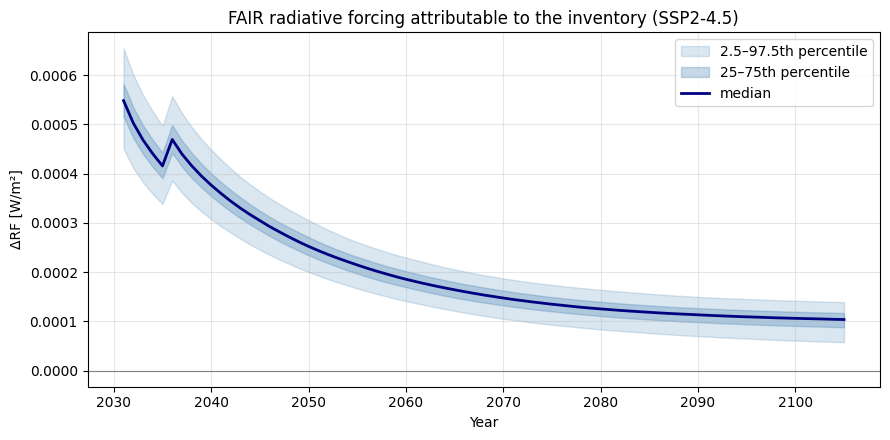

In [5]:
def total_by_quantile(df):
    """Sum the per-flow amount over flows, per (year, quantile)."""
    g = (
        df.assign(year=df["date"].dt.year)
        .groupby(["year", "quantile"])["amount"]
        .sum()
        .unstack("quantile")
    )
    return g


def plot_band(df, ylabel, title):
    g = total_by_quantile(df)
    fig, ax = plt.subplots(figsize=(9, 4.5))
    ax.fill_between(g.index, g[2.5], g[97.5], alpha=0.2, color='steelblue',
                    label='2.5–97.5th percentile')
    ax.fill_between(g.index, g[25.0], g[75.0], alpha=0.3, color='steelblue',
                    label='25–75th percentile')
    ax.plot(g.index, g[50.0], color='navy', lw=2, label='median')
    ax.axhline(0, color='grey', lw=0.8)
    ax.set_xlabel('Year')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


plot_band(df_rf, 'ΔRF [W/m²]',
          'FAIR radiative forcing attributable to the inventory (SSP2-4.5)')

### Temperature (ΔT)

The same call with `metric="fair_temperature"` returns the temperature anomaly ΔT [K].

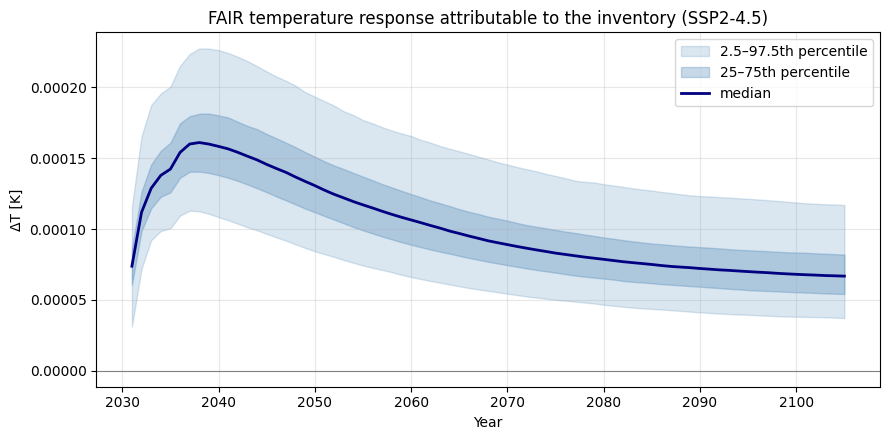

In [6]:
df_temp = characterize(
    dynamic_inventory_df,
    metric="fair_temperature",
    time_horizon=70,
)
plot_band(df_temp, 'ΔT [K]',
          'FAIR temperature response attributable to the inventory (SSP2-4.5)')

### Per-flow / per-activity attribution

Because the result is attributed per flow and activity, we can break the impact down by emitting activity. Here is the median ΔT trajectory for each activity.

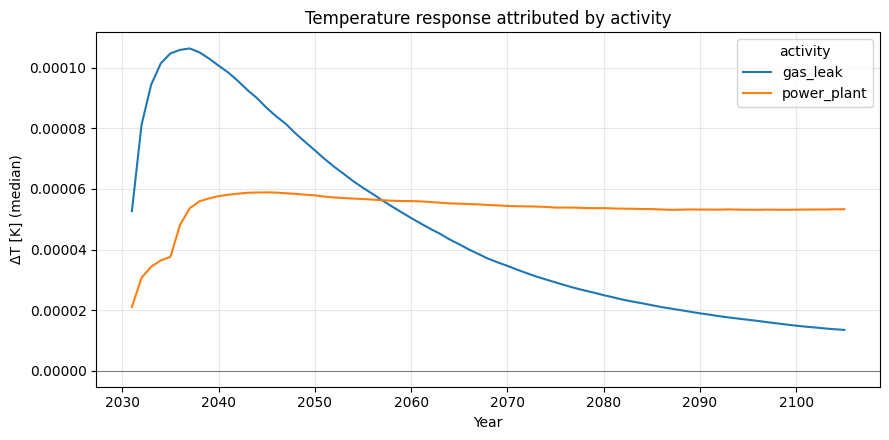

In [7]:
med = df_temp[df_temp['quantile'] == 50.0].copy()
med['year'] = med['date'].dt.year
pivot = med.pivot_table(index='year', columns='activity', values='amount', aggfunc='sum')

fig, ax = plt.subplots(figsize=(9, 4.5))
pivot.plot(ax=ax)
ax.axhline(0, color='grey', lw=0.8)
ax.set_xlabel('Year')
ax.set_ylabel('ΔT [K] (median)')
ax.set_title('Temperature response attributed by activity')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Comparing FAIR background scenarios

The marginal climate response of the *same* inventory depends (slightly, via the nonlinear carbon cycle and climate state) on the SSP background it is added to. Let's compare the median ΔT under a low and a high background pathway.

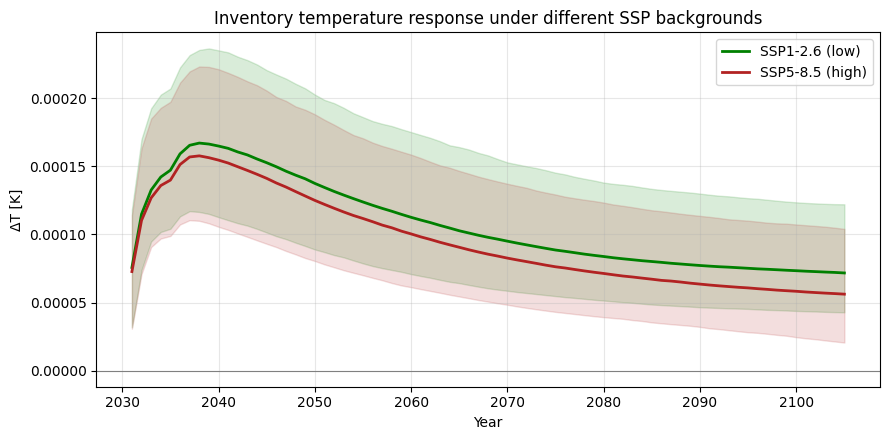

In [8]:
scenarios = [
    (("FAIR", "SSP1", "2.6"), "SSP1-2.6 (low)", "green"),
    (("FAIR", "SSP5", "8.5"), "SSP5-8.5 (high)", "firebrick"),
]

fig, ax = plt.subplots(figsize=(9, 4.5))
for (iam, ssp, rcp), label, color in scenarios:
    prospective.set_scenario(iam=iam, ssp=ssp, rcp=rcp)
    df = characterize(dynamic_inventory_df, metric='fair_temperature', time_horizon=70)
    g = total_by_quantile(df)
    ax.plot(g.index, g[50.0], color=color, lw=2, label=label)
    ax.fill_between(g.index, g[2.5], g[97.5], alpha=0.15, color=color)

ax.axhline(0, color='grey', lw=0.8)
ax.set_xlabel('Year')
ax.set_ylabel('ΔT [K]')
ax.set_title('Inventory temperature response under different SSP backgrounds')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Use via Brightway + `bw_temporalis`

In a real workflow the dynamic inventory comes from a temporal LCA. The FAIR path then looks up the biosphere **flow names automatically** from the inventory's `flow` ids — you do not need to add a `flow_name` column yourself.

> The cells below require the ecoinvent biosphere database and `bw_temporalis`, so they are provided as a runnable template (not executed in this published notebook).

### Brightway setup

In [ ]:
import bw2data as bd
import bw2io as bi

if "fair_demo" not in bd.projects:
    bi.remote.install_project('ecoinvent-3.10-biosphere', 'fair_demo',
                              overwrite_existing=True)  # no license required
bd.projects.set_current("fair_demo")

### A small production system with temporally distributed emissions

In [ ]:
import numpy as np
from bw_temporalis import TemporalDistribution

co2 = bd.get_node(database='ecoinvent-3.10-biosphere',
                  name='Carbon dioxide, fossil', categories=('air',))
ch4 = bd.get_node(database='ecoinvent-3.10-biosphere',
                  name='Methane, fossil', categories=('air',))

bd.Database('fair_test_db').write({
    ('fair_test_db', 'A'): {
        'name': 'A', 'location': 'GLO', 'reference product': 'A',
        'exchanges': [
            {'amount': 1, 'type': 'production', 'input': ('fair_test_db', 'A')},
            {'amount': 1e11, 'type': 'biosphere', 'input': co2.key,
             'temporal_distribution': TemporalDistribution(
                 np.array([0, 5], dtype='timedelta64[Y]'), np.array([0.6, 0.4]))},
            {'amount': 2e9, 'type': 'biosphere', 'input': ch4.key,
             'temporal_distribution': TemporalDistribution(
                 np.array([0], dtype='timedelta64[Y]'), np.array([1.0]))},
        ],
    },
})

### Dynamic LCA → dynamic inventory

In [ ]:
import bw2calc as bc
from bw_temporalis import TemporalisLCA

method = ('EF v3.1', 'climate change', 'global warming potential (GWP100)')
lca = bc.LCA({('fair_test_db', 'A'): 1}, method)
lca.lci()
lca.lcia()

tlca = TemporalisLCA(lca, starting_datetime='2030-01-01')
tl = tlca.build_timeline()
tl.build_dataframe()
tl.df

### FAIR characterization through Brightway

Pass the temporal inventory straight to `characterize()` with a FAIR metric. The flow names are resolved from the biosphere automatically; just set a FAIR-capable scenario first.

In [ ]:
import dynamic_characterization.prospective as prospective
from dynamic_characterization import characterize

prospective.set_scenario(iam='FAIR', ssp='SSP2', rcp='4.5')

df_temp_bw = characterize(
    tl.df,
    metric='fair_temperature',
    base_lcia_method=method,  # used to resolve which biosphere flows appear
    time_horizon=70,
)
df_temp_bw.head()

From here the per-flow, per-quantile output can be plotted exactly as in Section 1 (e.g. with `plot_band` / the attribution pivot).